<a href="https://colab.research.google.com/github/Dk-cse/Online-Food-Ordering-Dataset/blob/main/Online_Food_Ordering_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **Import CSV And convert to DataFrame**

In [3]:
df = pd.read_csv('/content/online food delivery dataset-selected-columns.csv')

Preprocessing

In [4]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533


In [5]:
df.tail()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,Regular,12.9770,77.5773
387,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.8988,77.5764


# **Shape of our dataset**

In [6]:
df.shape

(388, 10)

# **List out all columns**

In [7]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude'],
      dtype='object')

# **Datatype of each columns**

In [8]:
df.dtypes

,0
Age,int64
Gender,object
Marital Status,object
Occupation,object
Monthly Income,object
Educational Qualifications,object
Family size,int64
Customer Type,object
latitude,float64
longitude,float64


# **Information of all Columns**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 30.4+ KB


# **Check Null Value**


In [10]:
df.isnull().sum()

,0
Age,0
Gender,0
Marital Status,0
Occupation,0
Monthly Income,0
Educational Qualifications,0
Family size,0
Customer Type,0
latitude,0
longitude,0


# **Check Dupicate Value**

In [11]:
df.duplicated().sum()

np.int64(109)

# **Summary**

In [12]:
df.describe()

,Age,Family size,latitude,longitude
count,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160
std,2.975593,1.351025,0.044489,0.051354
min,18.000000,1.000000,12.865200,77.484200
25%,23.000000,2.000000,12.936900,77.565275
50%,24.000000,3.000000,12.977000,77.592100
75%,26.000000,4.000000,12.997025,77.630900
max,33.000000,6.000000,13.102000,77.758200


# **EDA**

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

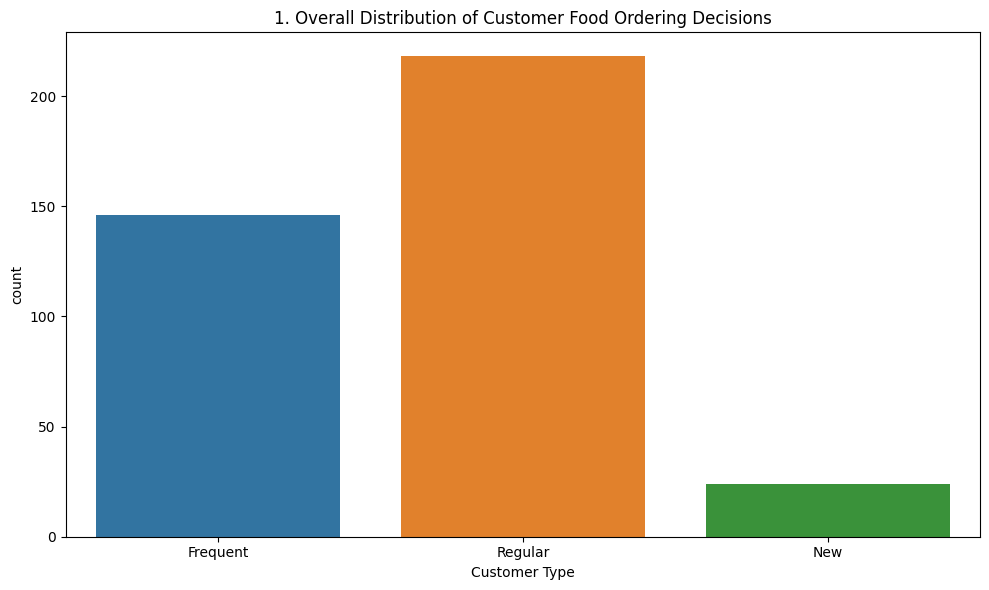

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Customer Type', hue='Customer Type', legend=False)
plt.title(f'{plot_no}. Overall Distribution of Customer Food Ordering Decisions')
show_fig()
plot_no += 1

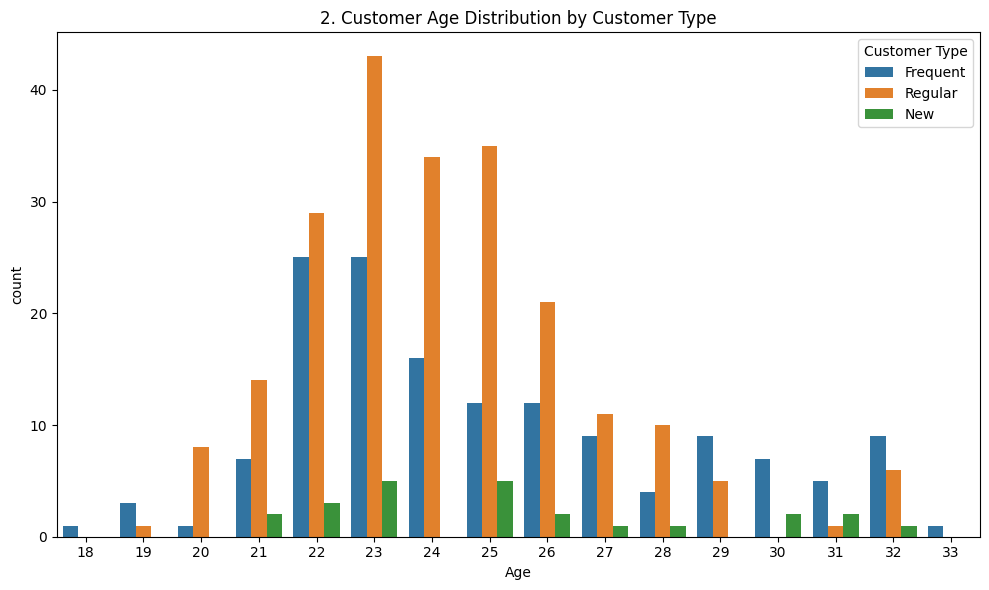

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Age', hue='Customer Type')
plt.title(f'{plot_no}. Customer Age Distribution by Customer Type')
show_fig()
plot_no += 1

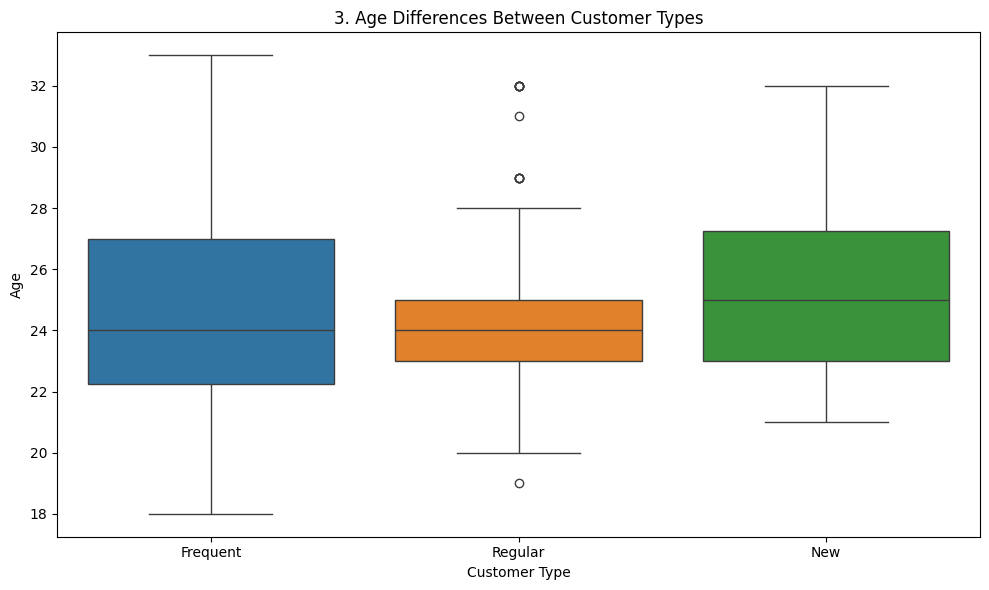

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Customer Type', y='Age', hue='Customer Type', legend=False)
plt.title(f'{plot_no}. Age Differences Between Customer Types')
show_fig()
plot_no += 1

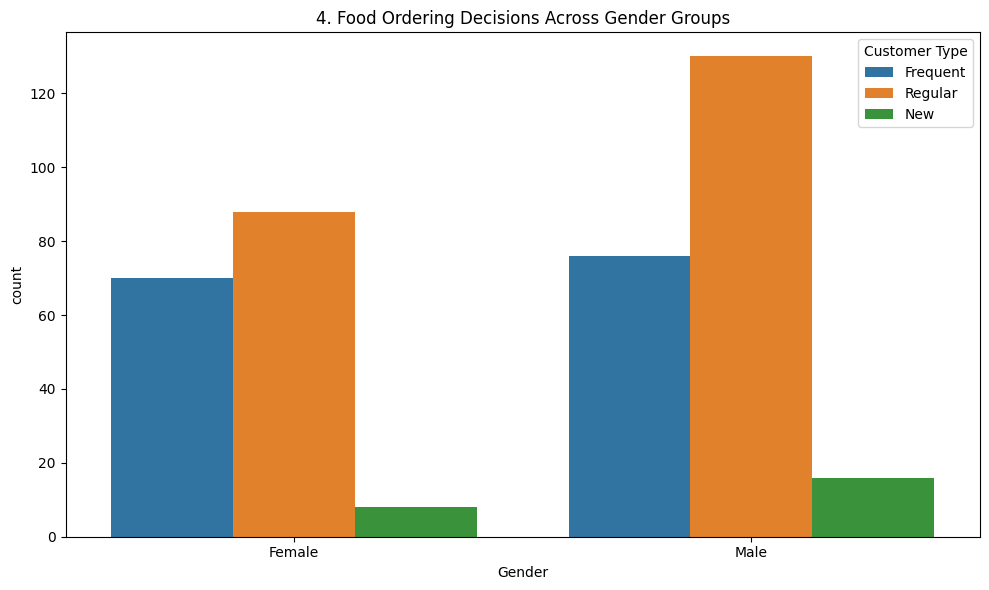

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='Customer Type')
plt.title(f'{plot_no}. Food Ordering Decisions Across Gender Groups')
show_fig()
plot_no += 1

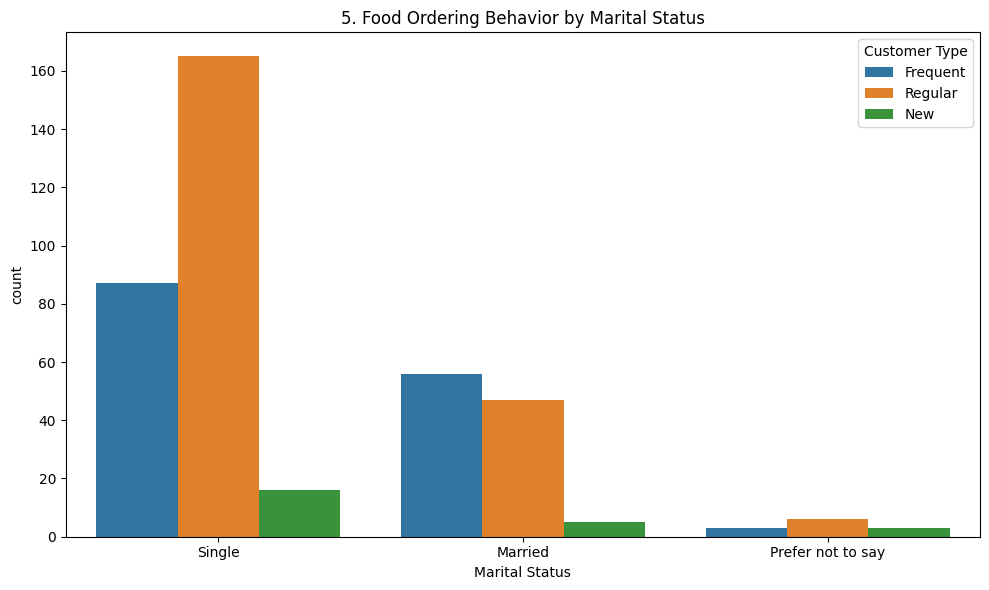

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Marital Status', hue='Customer Type')
plt.title(f'{plot_no}. Food Ordering Behavior by Marital Status')
show_fig()
plot_no += 1

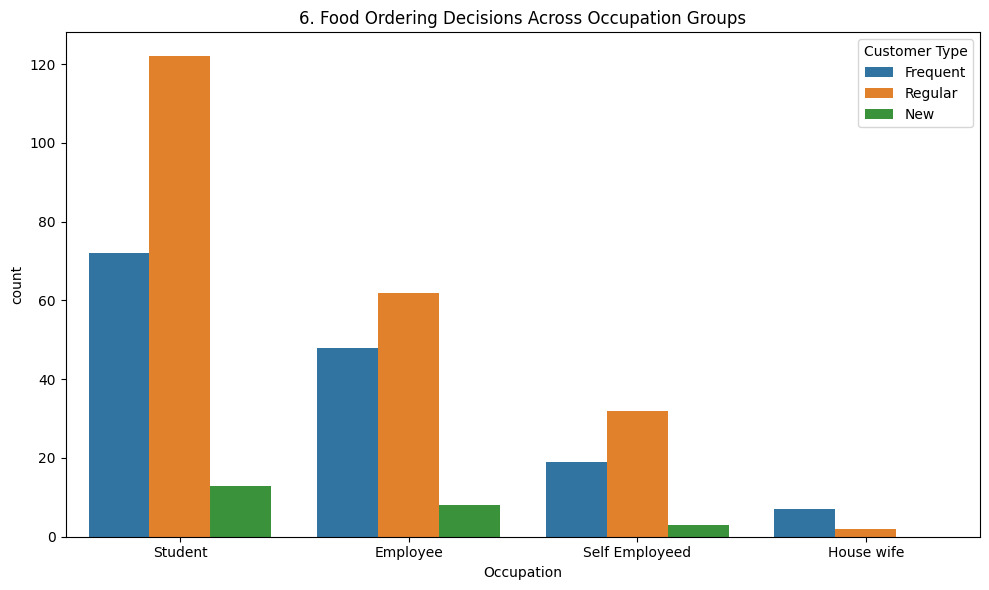

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Occupation', hue='Customer Type')
plt.title(f'{plot_no}. Food Ordering Decisions Across Occupation Groups')
show_fig()
plot_no += 1

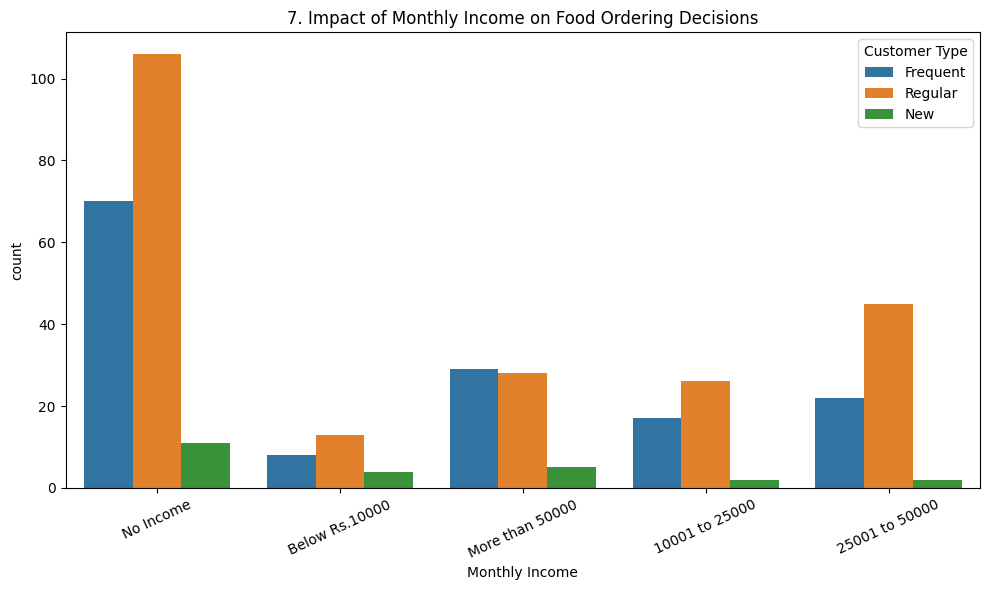

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Monthly Income', hue='Customer Type')
plt.title(f'{plot_no}. Impact of Monthly Income on Food Ordering Decisions')
plt.xticks(rotation=25)
show_fig()
plot_no += 1

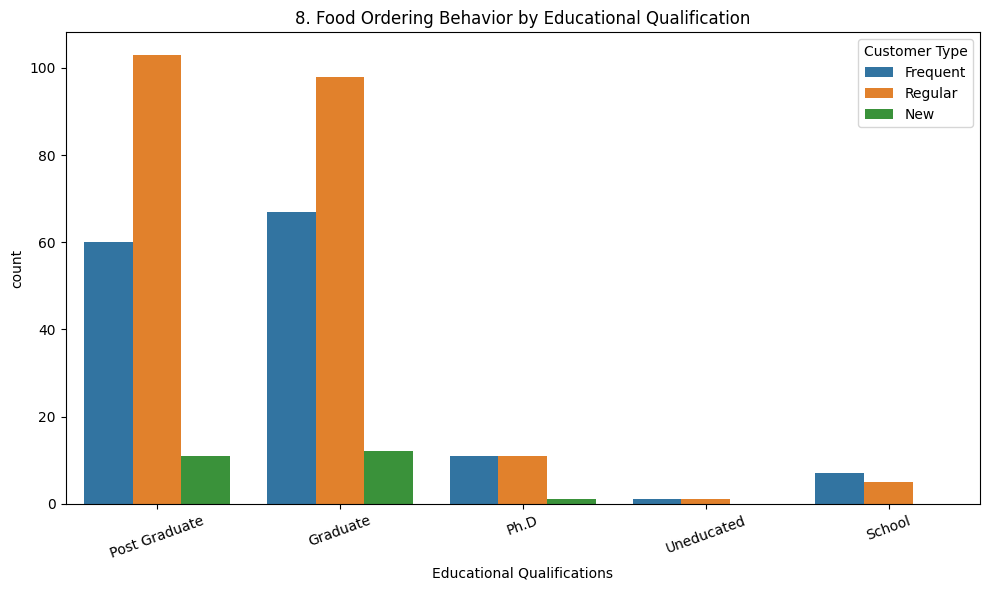

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Educational Qualifications', hue='Customer Type')
plt.title(f'{plot_no}. Food Ordering Behavior by Educational Qualification')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

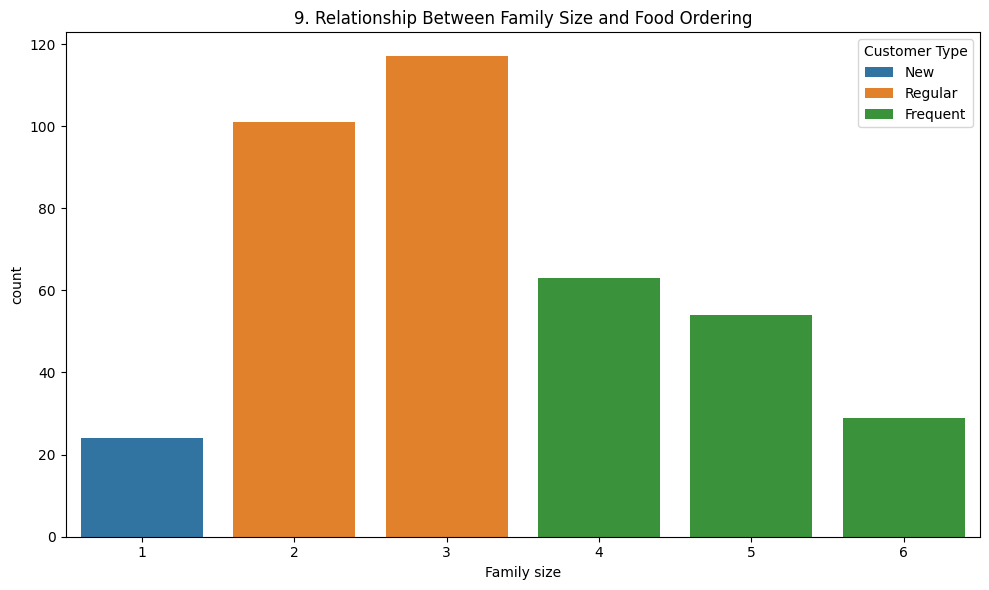

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Family size', hue='Customer Type')
plt.title(f'{plot_no}. Relationship Between Family Size and Food Ordering')
show_fig()
plot_no += 1

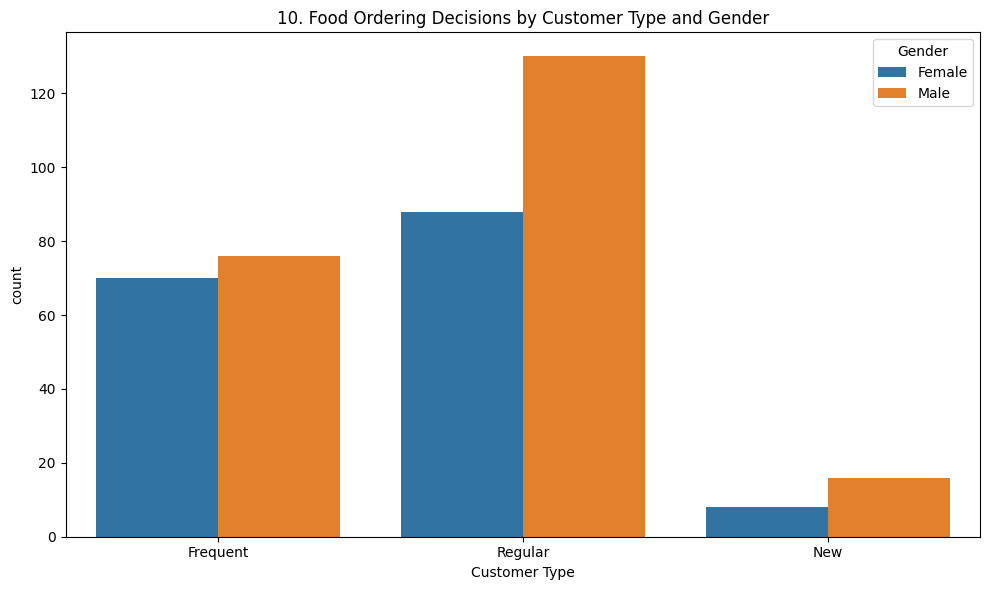

In [33]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Customer Type', hue='Gender')
plt.title(f'{plot_no}. Food Ordering Decisions by Customer Type and Gender')
show_fig()
plot_no += 1

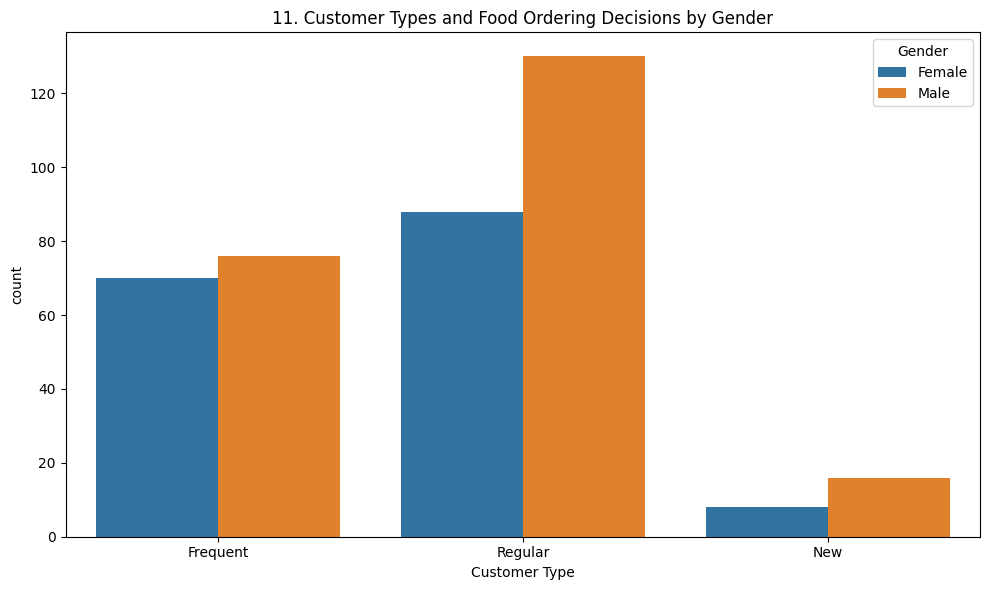

In [35]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Customer Type', hue='Gender')
plt.title(f'{plot_no}. Customer Types and Food Ordering Decisions by Gender')
show_fig()
plot_no += 1

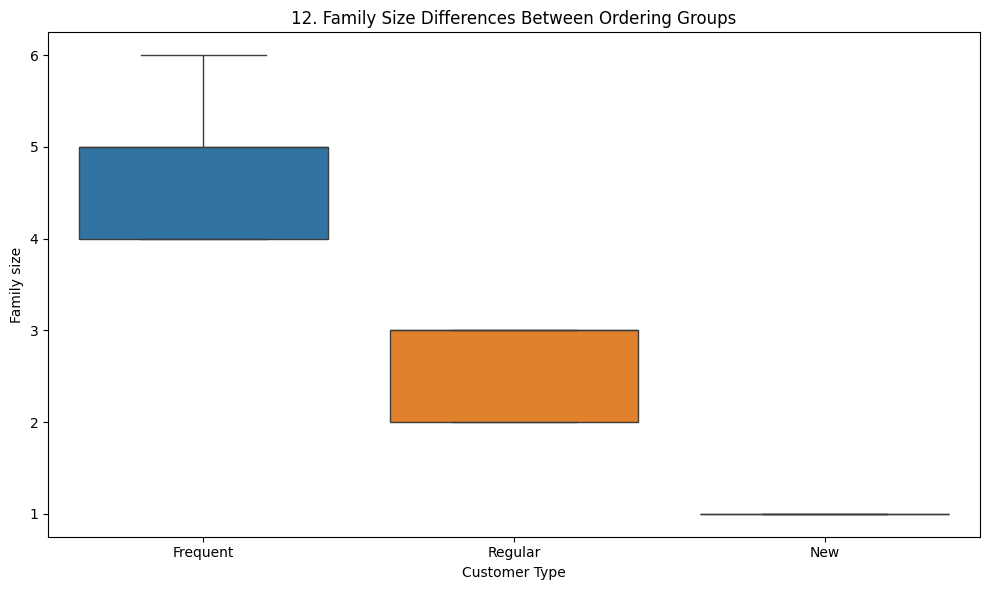

In [37]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Customer Type', y='Family size', hue='Customer Type', legend=False)
plt.title(f'{plot_no}. Family Size Differences Between Ordering Groups')
show_fig()
plot_no += 1

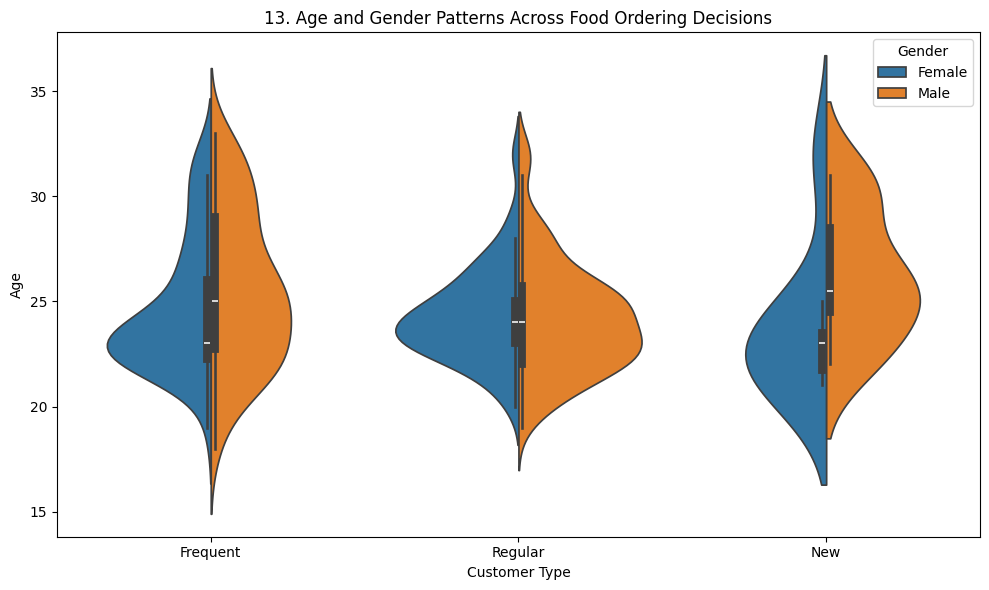

In [39]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Customer Type', y='Age', hue='Gender', split=True)
plt.title(f'{plot_no}. Age and Gender Patterns Across Food Ordering Decisions')
show_fig()
plot_no += 1

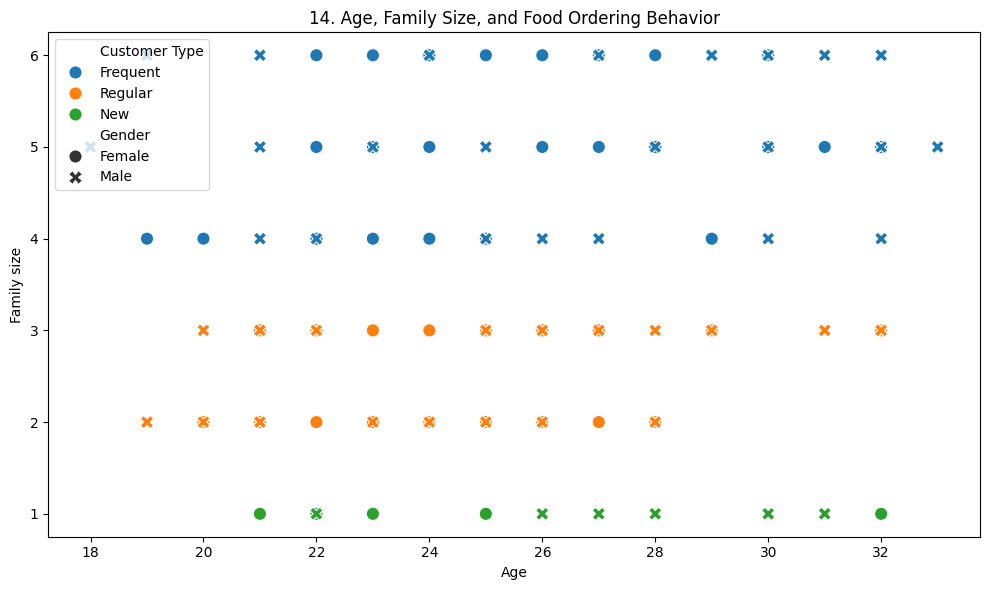

In [41]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Family size', hue='Customer Type', style='Gender', s=90)
plt.title(f'{plot_no}. Age, Family Size, and Food Ordering Behavior')
show_fig()
plot_no += 1

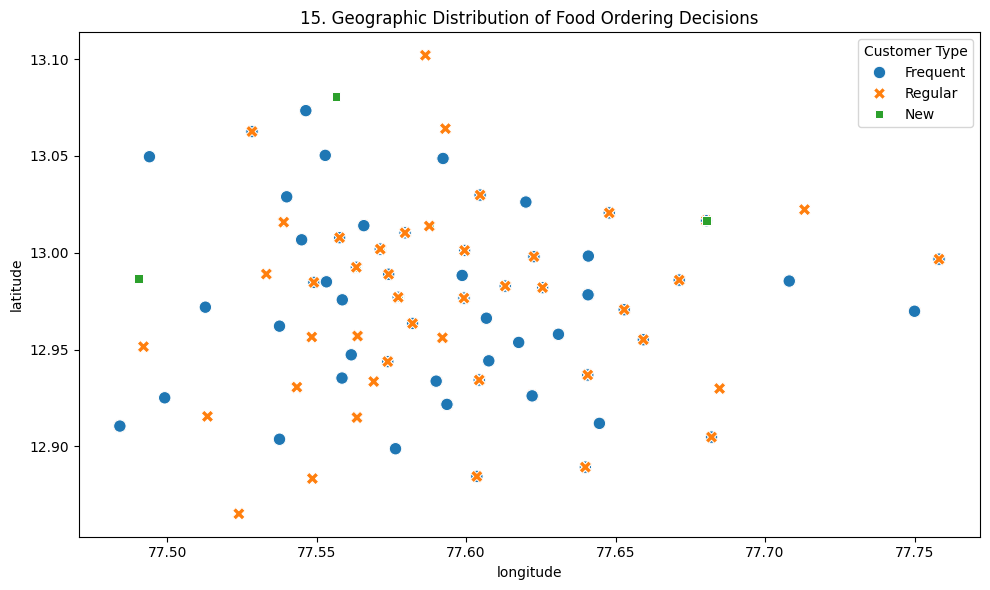

In [43]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='Customer Type', style='Customer Type', s=80)
plt.title(f'{plot_no}. Geographic Distribution of Food Ordering Decisions')
show_fig()
plot_no += 1

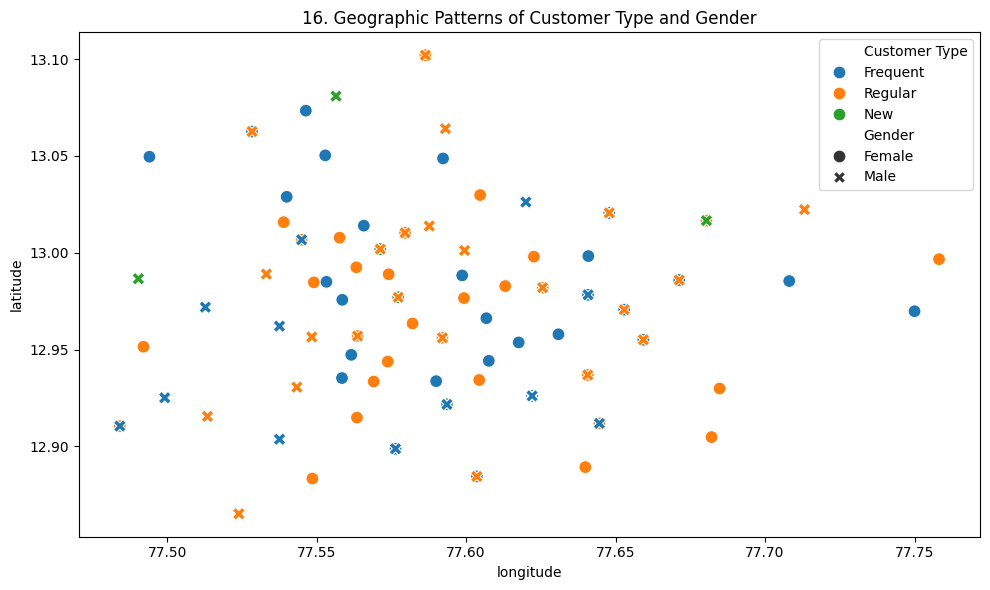

In [45]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='Customer Type', style='Gender', s=85)
plt.title(f'{plot_no}. Geographic Patterns of Customer Type and Gender')
show_fig()
plot_no += 1

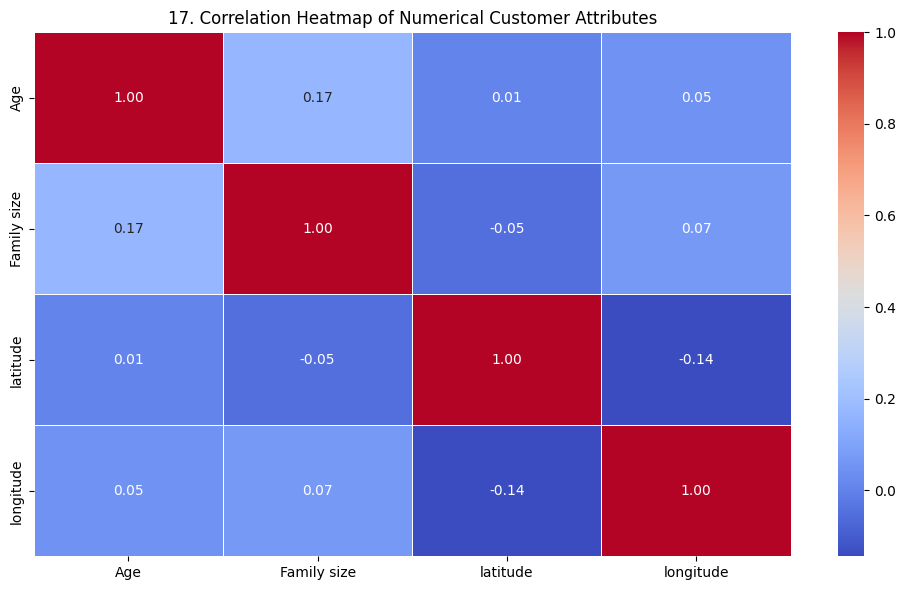

In [46]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Customer Attributes')
show_fig()
plot_no += 1

# **Model Training**

Prepare features and target

In [48]:
X = df.drop(columns=['Customer Type'], errors='ignore')
y = df['Customer Type']

# **Data Cleaning and Preprocessing**

In [49]:
# Remove duplicates
df_clean = df.drop_duplicates()
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

# Redefine X and y after cleaning
X = df_clean.drop(columns=['Customer Type'])
y = df_clean['Customer Type']

# Define categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Preprocessing pipeline created and data split into train/test sets.")

Original shape: (388, 10)
Cleaned shape: (279, 10)
Preprocessing pipeline created and data split into train/test sets.


# **Model Training and Evaluation**

Model Accuracy: 100.00%


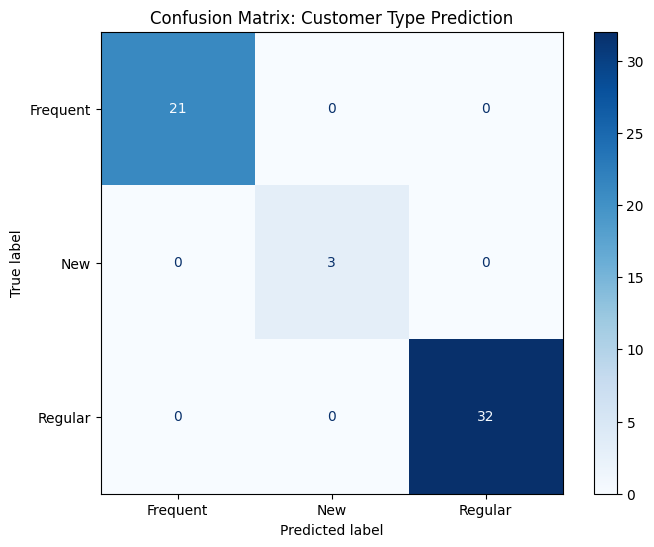

In [50]:
# Create a pipeline that combines the preprocessor with a Gradient Boosting Classifier
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Customer Type Prediction')
plt.show()